<a href="https://colab.research.google.com/github/Kriti-2180/Deep-Learning/blob/main/MLPmemorizationP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
np.random.seed(42)
tf.random.set_seed(42)

In [15]:
X_train = np.array([
    [1, 4, 50],
    [2, 5, 55],
    [3, 5, 60],
    [4, 6, 65],
    [5, 7, 75],
    [6, 7, 80],
    [7, 8, 85],
    [8, 8, 90],
    [9, 8, 95],
    [10, 9, 98]
], dtype=float)

y_train = np.array([
    0, 0, 0, 0, 1, 1, 1, 1, 1, 1
], dtype=float)

In [16]:
X_test = np.array([
    [1.5, 4.5, 52],
    [2.5, 5.5, 58],
    [3.5, 5.5, 63],
    [4.5, 6.5, 70],
    [5.5, 7.5, 78],
    [6.5, 7.5, 82],
    [7.5, 8.5, 88],
    [8.5, 8.5, 92]
], dtype=float)

y_test = np.array([
    0, 0, 0, 1, 1, 1, 1, 1
], dtype=float)

In [17]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[:, 0] /= 10
X_train_scaled[:, 1] /= 10
X_train_scaled[:, 2] /= 100

X_test_scaled[:, 0] /= 10
X_test_scaled[:, 1] /= 10
X_test_scaled[:, 2] /= 100

In [18]:
# Big MLP model
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=300,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1000 - loss: 0.6977 - val_accuracy: 0.6250 - val_loss: 0.6896
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6000 - loss: 0.6907 - val_accuracy: 0.6250 - val_loss: 0.6822
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6000 - loss: 0.6834 - val_accuracy: 0.6250 - val_loss: 0.6758
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6000 - loss: 0.6768 - val_accuracy: 0.6250 - val_loss: 0.6703
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6000 - loss: 0.6712 - val_accuracy: 0.6250 - val_loss: 0.6649
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6000 - loss: 0.6657 - val_accuracy: 0.6250 - val_loss: 0.6595
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6000 - loss: 0.6604 - val_accuracy: 0.6250 - val_loss: 0.6541
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6000 - loss: 0.6550 - val_accuracy: 0.6250 - val_loss: 

In [21]:
train_loss, train_acc = model.evaluate(
    X_train_scaled,
    y_train,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

print("Training Loss:", train_loss)
print("Testing Loss:", test_loss)

Training Accuracy: 1.0
Testing Accuracy: 1.0
Training Loss: 0.0021560215391218662
Testing Loss: 0.08216539025306702


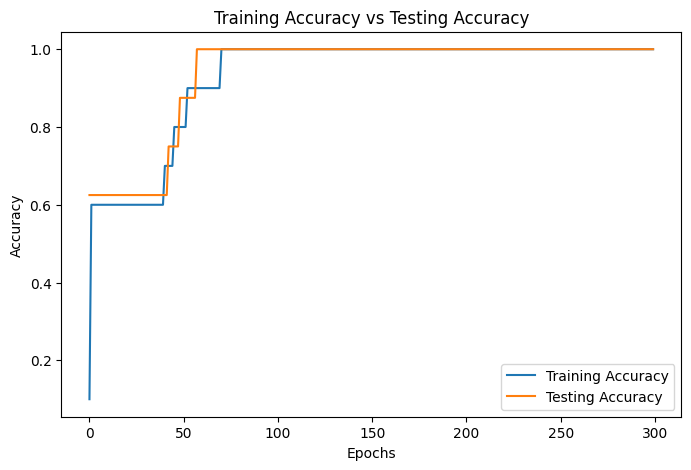

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Testing Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Testing Accuracy")

plt.legend()
plt.show()

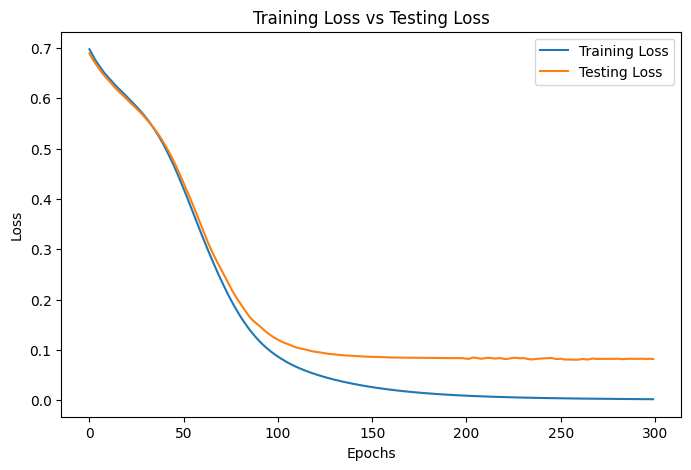

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Testing Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Testing Loss")

plt.legend()
plt.show()

In [24]:
predictions = model.predict(X_test_scaled)

for i in range(len(X_test_scaled)):

    probability = predictions[i][0]

    predicted_class = 1 if probability >= 0.5 else 0

    print(
        "Student:",
        X_test[i],
        "| Actual:",
        int(y_test[i]),
        "| Probability:",
        round(probability, 3),
        "| Predicted:",
        predicted_class
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
Student: [ 1.5  4.5 52. ] | Actual: 0 | Probability: 0.0 | Predicted: 0
Student: [ 2.5  5.5 58. ] | Actual: 0 | Probability: 0.0 | Predicted: 0
Student: [ 3.5  5.5 63. ] | Actual: 0 | Probability: 0.001 | Predicted: 0
Student: [ 4.5  6.5 70. ] | Actual: 1 | Probability: 0.519 | Predicted: 1
Student: [ 5.5  7.5 78. ] | Actual: 1 | Probability: 1.0 | Predicted: 1
Student: [ 6.5  7.5 82. ] | Actual: 1 | Probability: 1.0 | Predicted: 1
Student: [ 7.5  8.5 88. ] | Actual: 1 | Probability: 1.0 | Predicted: 1
Student: [ 8.5  8.5 92. ] | Actual: 1 | Probability: 1.0 | Predicted: 1
